<a href="https://colab.research.google.com/github/dheep2305-git/Tsf-tasks/blob/main/tsf_task_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install influxdb-client

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import SYNCHRONOUS

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 829.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 746.3/746.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 257.3/257.3 kB 18.3 MB/s eta 0:00:00


In [ ]:
# Create time index

time = pd.date_range(
    start="2024-01-01",
    periods=50,
    freq="D"
)

In [ ]:
# Generate components

trend = np.linspace(10, 30, 50)

seasonality = 5 * np.sin(
    np.linspace(0, 10, 50)
)

noise = np.random.normal(0, 1, 50)

In [ ]:
# Combine

values = trend + seasonality + noise

In [ ]:
# Create DataFrame

df = pd.DataFrame({
    "time": time,
    "value": values
})

df.set_index("time", inplace=True)

print(df.head())

                value
time                 
2024-01-01   9.189092
2024-01-02  10.862372
2024-01-03  13.423435
2024-01-04  15.412140
2024-01-05  14.526329


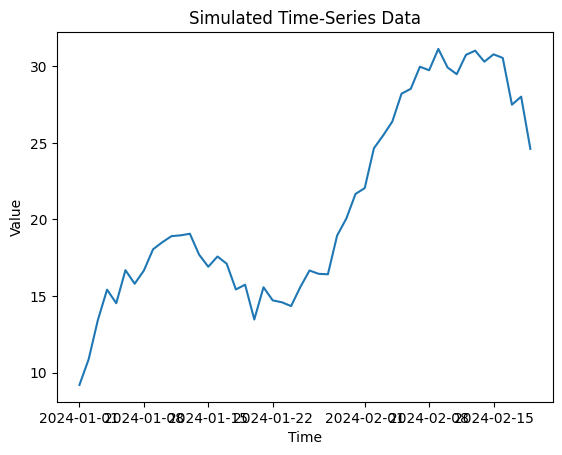

In [ ]:
# Plot

plt.plot(df.index, df["value"])

plt.title("Simulated Time-Series Data")

plt.xlabel("Time")
plt.ylabel("Value")

plt.show()

In [ ]:
# Configure InfluxDB Cloud

# Replace with your InfluxDB Cloud URL
url = "https://your-region.cloud2.influxdata.com"

# Replace with your InfluxDB Cloud Token
token = "your_token"

# Replace with your InfluxDB Cloud Organization
org = "your_org"

# Replace with your InfluxDB Cloud Bucket
bucket = "your_bucket"

In [ ]:
# Connect to InfluxDB

client = InfluxDBClient(
    url=url,
    token=token,
    org=org
)

write_api = client.write_api(
    write_options=SYNCHRONOUS
)

In [ ]:
from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import SYNCHRONOUS

In [ ]:
# Write Data to InfluxDB

for index, row in df.iterrows():

    point = Point("timeseries_data")
    point = point.field("value", float(row["value"]))
    point = point.time(index, WritePrecision.NS)

    write_api.write(
        bucket=bucket,
        org=org,
        record=point
    )

print("Data written successfully!")

NameResolutionError: <urllib3.connection.HTTPSConnection object at 0x7b2efd82c3e0>: Failed to resolve 'your-region.cloud2.influxdata.com' ([Errno -2] Name or service not known)